### Hexagon `807bfffffffffff`: vertices → `latlon2h3`

Extract the 6 vertices and the midpoint of each edge (`v1_v2`, …), convert each with `latlon2h3`, and plot. Each point and its assigned cell share a color. Cell IDs are labeled once on the geometries. Circles are vertices; squares are edge midpoints.

In [37]:
import math
import h3
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from vgrid.conversion.latlon2dggs import latlon2h3
from vgrid.conversion.dggs2geo.h32geo import h32geo


def spherical_midpoint(lat1, lon1, lat2, lon2):
    p1, l1, p2, l2 = map(math.radians, (lat1, lon1, lat2, lon2))
    x = math.cos(p1) * math.cos(l1) + math.cos(p2) * math.cos(l2)
    y = math.cos(p1) * math.sin(l1) + math.cos(p2) * math.sin(l2)
    z = math.sin(p1) + math.sin(p2)
    n = math.sqrt(x * x + y * y + z * z)
    x, y, z = x / n, y / n, z / n
    return math.degrees(math.asin(z)), math.degrees(math.atan2(y, x))


HEXAGON = "807bfffffffffff"
RES = 0
verts = list(h3.cell_to_boundary(HEXAGON))

rows = []
for i, (lat, lon) in enumerate(verts, 1):
    assigned = latlon2h3(lat, lon, RES)
    rows.append({"vertex": f"v{i}", "lat": lat, "lon": lon, "h3": assigned, "kind": "vertex"})
    print(f"v{i}  ({lat:10.6f}, {lon:11.6f})  ->  {assigned}")

print()
n = len(verts)
for i in range(n):
    lat1, lon1 = verts[i]
    lat2, lon2 = verts[(i + 1) % n]
    mlat, mlon = spherical_midpoint(lat1, lon1, lat2, lon2)
    name = f"v{i + 1}_v{(i + 1) % n + 1}"
    assigned = latlon2h3(mlat, mlon, RES)
    rows.append({"vertex": name, "lat": mlat, "lon": mlon, "h3": assigned, "kind": "mid"})
    print(f"{name}  ({mlat:10.6f}, {mlon:11.6f})  ->  {assigned}")

unique_cells = list(dict.fromkeys(r["h3"] for r in rows))
print(f"\n{n} vertices + {n} midpoints -> {len(unique_cells)} distinct cells: {unique_cells}")

v1  ( -8.931892,   52.885934)  ->  8085fffffffffff
v2  (  1.447643,   55.701507)  ->  807bfffffffffff
v3  (  9.876091,   48.701817)  ->  807bfffffffffff
v4  (  8.893463,   37.848935)  ->  8053fffffffffff
v5  ( -1.677295,   33.663619)  ->  806bfffffffffff
v6  (-11.222876,   41.579563)  ->  80a3fffffffffff

v1_v2  ( -3.743251,   54.302085)  ->  807bfffffffffff
v2_v3  (  5.672377,   52.227261)  ->  807bfffffffffff
v3_v4  (  9.426268,   43.267662)  ->  807bfffffffffff
v4_v5  (  3.610485,   35.744065)  ->  806bfffffffffff
v5_v6  ( -6.465374,   37.584171)  ->  8097fffffffffff
v6_v1  (-10.125619,   47.252903)  ->  80a3fffffffffff

6 vertices + 6 midpoints -> 6 distinct cells: ['8085fffffffffff', '807bfffffffffff', '8053fffffffffff', '806bfffffffffff', '80a3fffffffffff', '8097fffffffffff']


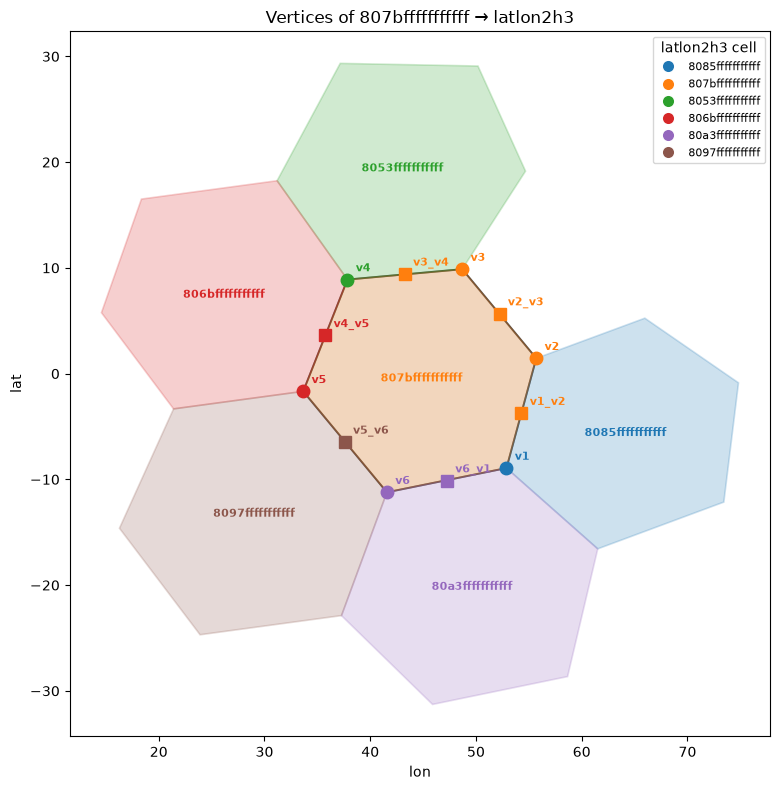

In [38]:
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
cell_color = {cid: palette[i % len(palette)] for i, cid in enumerate(unique_cells)}

fig, ax = plt.subplots(figsize=(9, 8))

pent_poly = h32geo(HEXAGON)
xs, ys = pent_poly.exterior.xy
ax.fill(xs, ys, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.4, alpha=0.9, zorder=1)

drawn = set()
for cid in unique_cells:
    if cid in drawn:
        continue
    drawn.add(cid)
    poly = h32geo(cid)
    color = cell_color[cid]
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, facecolor=color, edgecolor=color, linewidth=1.2, alpha=0.22, zorder=2)
    ax.annotate(
        cid,
        (poly.centroid.x, poly.centroid.y),
        ha="center",
        va="center",
        fontsize=8,
        color=color,
        fontweight="bold",
        zorder=5,
    )

for r in rows:
    color = cell_color[r["h3"]]
    marker = "o" if r["kind"] == "vertex" else "s"
    ax.plot(r["lon"], r["lat"], marker, color=color, markersize=9, zorder=6)
    ax.annotate(
        r["vertex"],
        (r["lon"], r["lat"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color=color,
        fontweight="bold",
        zorder=7,
    )

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=cell_color[cid], markersize=9, label=cid)
    for cid in unique_cells
]
ax.legend(handles=handles, title="latlon2h3 cell", fontsize=8, loc="best")
ax.set_aspect("equal")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"Vertices of {HEXAGON} → latlon2h3")
plt.tight_layout()
plt.show()

### S2 `17` (level 2): vertices → `latlon2s2`

Extract the 4 vertices and the midpoint of each edge (`v1_v2`, …), convert each with `latlon2s2` at the same level, and plot. Each point and its assigned cell share a color. Cell tokens are labeled once. Circles are vertices; squares are edge midpoints.

In [39]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from vgrid.conversion.latlon2dggs import latlon2s2
from vgrid.conversion.dggs2geo.s22geo import s22geo
from vgrid.dggs import s2

S2_TOKEN = "191"
s2_id = s2.CellId.from_token(S2_TOKEN)
S2_RES = s2_id.level()
s2_cell = s2.Cell(s2_id)
s2_xyz = [s2_cell.get_vertex(i) for i in range(4)]

s2_rows = []
for i, xyz in enumerate(s2_xyz, 1):
    ll = s2.LatLng.from_point(xyz)
    lat, lon = ll.lat().degrees, ll.lng().degrees
    assigned = latlon2s2(lat, lon, S2_RES)
    s2_rows.append({"vertex": f"v{i}", "lat": lat, "lon": lon, "s2": assigned, "kind": "vertex"})
    print(f"v{i}  ({lat:10.6f}, {lon:11.6f})  ->  {assigned}")

print()
for i in range(4):
    mid = (s2_xyz[i] + s2_xyz[(i + 1) % 4]).normalize()
    ll = s2.LatLng.from_point(mid)
    lat, lon = ll.lat().degrees, ll.lng().degrees
    name = f"v{i + 1}_v{(i + 1) % 4 + 1}"
    assigned = latlon2s2(lat, lon, S2_RES)
    s2_rows.append({"vertex": name, "lat": lat, "lon": lon, "s2": assigned, "kind": "mid"})
    print(f"{name}  ({lat:10.6f}, {lon:11.6f})  ->  {assigned}")

s2_unique = list(dict.fromkeys(r["s2"] for r in s2_rows))
print(f"\nlevel {S2_RES}: 4 vertices + 4 midpoints -> {len(s2_unique)} distinct cells: {s2_unique}")

v1  (-14.599413,   28.673146)  ->  191
v2  (-13.746703,   34.508523)  ->  18f
v3  ( -8.783195,   34.508523)  ->  185
v4  ( -9.341890,   28.673146)  ->  19b

v1_v2  (-14.190712,   31.596323)  ->  191
v2_v3  (-11.264949,   34.508523)  ->  18f
v3_v4  ( -9.074110,   31.593106)  ->  19b
v4_v1  (-11.970652,   28.673146)  ->  191

level 4: 4 vertices + 4 midpoints -> 4 distinct cells: ['191', '18f', '185', '19b']


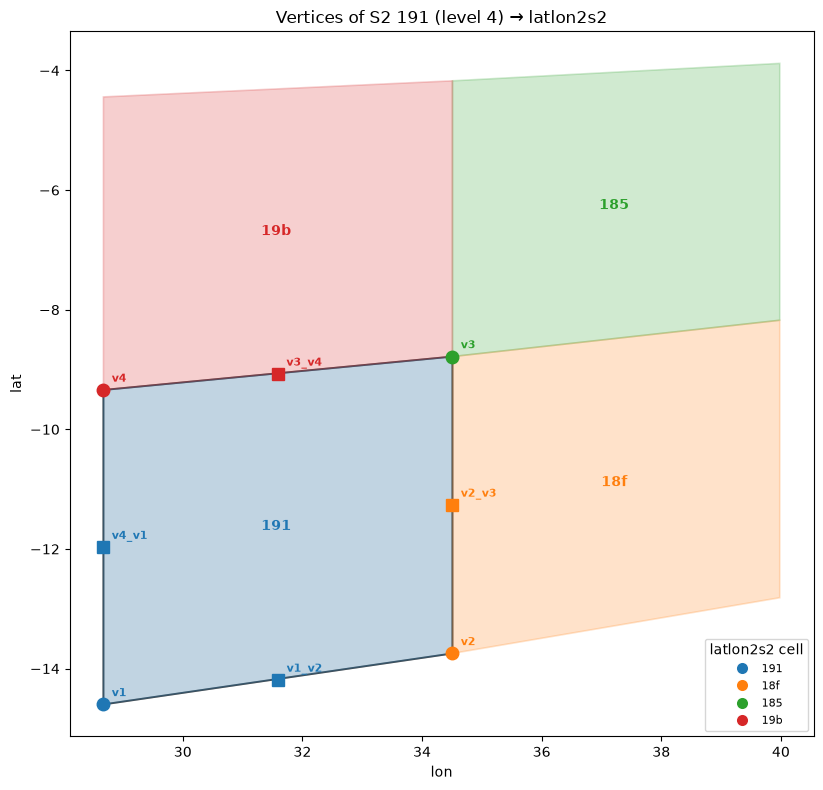

In [40]:
s2_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
s2_color = {cid: s2_palette[i] for i, cid in enumerate(s2_unique)}

fig, ax = plt.subplots(figsize=(9, 8))

input_poly = s22geo(S2_TOKEN)
xs, ys = input_poly.exterior.xy
ax.fill(xs, ys, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.4, alpha=0.9, zorder=1)

labeled = set()
for cid in s2_unique:
    poly = s22geo(cid)
    color = s2_color[cid]
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, facecolor=color, edgecolor=color, linewidth=1.2, alpha=0.22, zorder=2)
    if cid in labeled:
        continue
    labeled.add(cid)
    ax.annotate(
        cid,
        (poly.centroid.x, poly.centroid.y),
        ha="center",
        va="center",
        fontsize=10,
        color=color,
        fontweight="bold",
        zorder=5,
    )

for r in s2_rows:
    color = s2_color[r["s2"]]
    marker = "o" if r["kind"] == "vertex" else "s"
    ax.plot(r["lon"], r["lat"], marker, color=color, markersize=9, zorder=6)
    ax.annotate(
        r["vertex"],
        (r["lon"], r["lat"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color=color,
        fontweight="bold",
        zorder=7,
    )

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=s2_color[cid], markersize=9, label=cid)
    for cid in s2_unique
]
ax.legend(handles=handles, title="latlon2s2 cell", fontsize=8, loc="best")
ax.set_aspect("equal")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"Vertices of S2 {S2_TOKEN} (level {S2_RES}) → latlon2s2")
plt.tight_layout()
plt.show()

### How S2 assigns a shared vertex

A point on a vertex is not compared to neighboring cell IDs or centers. `CellId.from_point` picks **one cube face** (`largest_abs_component`: later axis wins on a tie), maps `(u, v)` → `(s, t)`, then **`floor`**. The cell that owns `[i, i+size) × [j, j+size)` wins — that is the cell for which this point is the min-`i`, min-`j` (SW in UV) corner. `parent(level)` only coarsens that leaf.

![How S2 chooses a cell for a shared vertex](s2_shared_vertex.png)

### How S2 assigns a shared-edge point

An edge interior is shared by **two** cells (not four). The lookup is the same `floor` as for vertices: a grid line `s = k / 2^L` or `t = m / 2^L` is the **min** side of the cell that starts there, so the point goes to the cell on the **+i** (vertical edge) or **+j** (horizontal edge) side. Each cell therefore owns its south and west UV edges; the north and east midpoints belong to the neighbor.

On a cube-face boundary the face is chosen first (`largest_abs_component`), then the same half-open rule applies on that face.

![How S2 chooses a cell for a shared-edge point](s2_shared_edge.png)

### How S2 assigns a contained (interior) point

There is no extra interior rule. `latlon2s2` always runs `CellId.from_point` then `parent(level)`. If `(s, t)` is **strictly inside** the cell’s half-open square `[i, i+size) × [j, j+size)`, `floor` cannot land on a neighbor, so the point belongs to this cell only.

`Cell.contains(point)` is a related but slightly different test: it checks a **closed** UV box (`u_lo ≤ u ≤ u_hi` and `v_lo ≤ v ≤ v_hi`) on this face. In the open interior the two agree. On the max-`i` / max-`j` edges `contains` can still be true while `from_point` assigns the neighbor.

![How S2 assigns a contained (interior) point](s2_contained_point.png)

### A5 `6da0000000000000` (res 3): vertices and edge midpoints → `latlon2a5`

Extract the 5 vertices and the midpoint of each edge (`v1_v2`, …), convert each with `latlon2a5` at the same resolution, and plot. Circles are vertices; squares are edge midpoints. Each point and its assigned cell share a color. Cell IDs are labeled once.

In [41]:
import math
import a5
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from vgrid.conversion.latlon2dggs import latlon2a5
from vgrid.conversion.dggs2geo.a52geo import a52geo


def spherical_midpoint(lat1, lon1, lat2, lon2):
    p1, l1, p2, l2 = map(math.radians, (lat1, lon1, lat2, lon2))
    x = math.cos(p1) * math.cos(l1) + math.cos(p2) * math.cos(l2)
    y = math.cos(p1) * math.sin(l1) + math.cos(p2) * math.sin(l2)
    z = math.sin(p1) + math.sin(p2)
    n = math.sqrt(x * x + y * y + z * z)
    x, y, z = x / n, y / n, z / n
    return math.degrees(math.asin(z)), math.degrees(math.atan2(y, x))


A5_ID = "6da0000000000000"
A5_OPTS = {"segments": 1}
a5_u64 = a5.hex_to_u64(A5_ID)
A5_RES = a5.get_resolution(a5_u64)
# cell_to_boundary returns (lon, lat); last point repeats the first
a5_verts = a5.cell_to_boundary(a5_u64, A5_OPTS)[:-1]

a5_rows = []
for i, (lon, lat) in enumerate(a5_verts, 1):
    assigned = latlon2a5(lat, lon, A5_RES)
    a5_rows.append({"vertex": f"v{i}", "lat": lat, "lon": lon, "a5": assigned, "kind": "vertex"})
    print(f"v{i}  ({lat:10.6f}, {lon:11.6f})  ->  {assigned}")

print()
n = len(a5_verts)
for i in range(n):
    lon1, lat1 = a5_verts[i]
    lon2, lat2 = a5_verts[(i + 1) % n]
    mlat, mlon = spherical_midpoint(lat1, lon1, lat2, lon2)
    name = f"v{i + 1}_v{(i + 1) % n + 1}"
    assigned = latlon2a5(mlat, mlon, A5_RES)
    a5_rows.append({"vertex": name, "lat": mlat, "lon": mlon, "a5": assigned, "kind": "mid"})
    print(f"{name}  ({mlat:10.6f}, {mlon:11.6f})  ->  {assigned}")

a5_unique = list(dict.fromkeys(r["a5"] for r in a5_rows))
print(f"\nres {A5_RES}: {n} vertices + {n} midpoints -> {len(a5_unique)} distinct cells: {a5_unique}")

v1  ( 14.932276,   34.771920)  ->  6ca0000000000000
v2  (  9.762943,   32.676184)  ->  6ca0000000000000
v3  (  9.549361,   37.881935)  ->  6da0000000000000
v4  ( 13.628636,   41.579143)  ->  6da0000000000000
v5  ( 18.344366,   39.084351)  ->  6e20000000000000

v1_v2  ( 12.349611,   33.713696)  ->  6ca0000000000000
v2_v3  (  9.665937,   35.279885)  ->  6da0000000000000
v3_v4  ( 11.594870,   39.717033)  ->  6d60000000000000
v4_v5  ( 15.990096,   40.346464)  ->  6e20000000000000
v5_v1  ( 16.649457,   36.908934)  ->  6da0000000000000

res 3: 5 vertices + 5 midpoints -> 4 distinct cells: ['6ca0000000000000', '6da0000000000000', '6e20000000000000', '6d60000000000000']


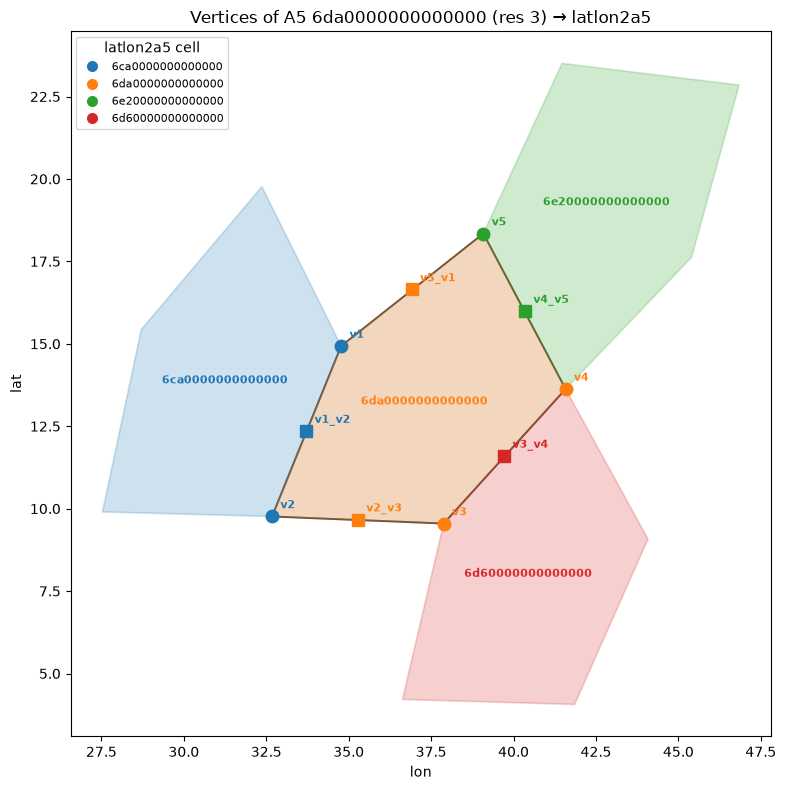

In [42]:
a5_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
a5_color = {cid: a5_palette[i % len(a5_palette)] for i, cid in enumerate(a5_unique)}

fig, ax = plt.subplots(figsize=(9, 8))

input_poly = a52geo(A5_ID, options=A5_OPTS)
xs, ys = input_poly.exterior.xy
ax.fill(xs, ys, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.4, alpha=0.9, zorder=1)

labeled = set()
for cid in a5_unique:
    poly = a52geo(cid, options=A5_OPTS)
    color = a5_color[cid]
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, facecolor=color, edgecolor=color, linewidth=1.2, alpha=0.22, zorder=2)
    if cid in labeled:
        continue
    labeled.add(cid)
    ax.annotate(
        cid,
        (poly.centroid.x, poly.centroid.y),
        ha="center",
        va="center",
        fontsize=8,
        color=color,
        fontweight="bold",
        zorder=5,
    )

for r in a5_rows:
    color = a5_color[r["a5"]]
    marker = "o" if r["kind"] == "vertex" else "s"
    ax.plot(r["lon"], r["lat"], marker, color=color, markersize=9, zorder=6)
    ax.annotate(
        r["vertex"],
        (r["lon"], r["lat"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color=color,
        fontweight="bold",
        zorder=7,
    )

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=a5_color[cid], markersize=9, label=cid)
    for cid in a5_unique
]
ax.legend(handles=handles, title="latlon2a5 cell", fontsize=8, loc="best")
ax.set_aspect("equal")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"Vertices of A5 {A5_ID} (res {A5_RES}) → latlon2a5")
plt.tight_layout()
plt.show()